In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('/content/datalab_export_2026-05-28 16_00_05.csv')

In [4]:
df

,index,Date,Rented Bike Count,Hour,Temperature(C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0,Winter,No Holiday,Yes
1,1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0,Winter,No Holiday,Yes
2,2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0,Winter,No Holiday,Yes
3,3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0,Winter,No Holiday,Yes
4,4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0,Winter,No Holiday,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,95,04/12/2017,248,23,-5.8,44,2.4,2000,-16.1,0.0,0.0,0,Winter,No Holiday,Yes
96,96,05/12/2017,216,0,-6.1,42,2.6,2000,-16.9,0.0,0.0,0,Winter,No Holiday,Yes
97,97,05/12/2017,198,1,-6.5,41,2.8,2000,-17.6,0.0,0.0,0,Winter,No Holiday,Yes
98,98,05/12/2017,124,2,-6.8,41,2.5,2000,-17.8,0.0,0.0,0,Winter,No Holiday,Yes


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   index                     100 non-null    int64  
 1   Date                      100 non-null    object 
 2   Rented Bike Count         100 non-null    int64  
 3   Hour                      100 non-null    int64  
 4   Temperature(C)            100 non-null    float64
 5   Humidity(%)               100 non-null    int64  
 6   Wind speed (m/s)          100 non-null    float64
 7   Visibility (10m)          100 non-null    int64  
 8   Dew point temperature(C)  100 non-null    float64
 9   Solar Radiation (MJ/m2)   100 non-null    float64
 10  Rainfall(mm)              100 non-null    float64
 11  Snowfall (cm)             100 non-null    int64  
 12  Seasons                   100 non-null    object 
 13  Holiday                   100 non-null    object 
 14  Functioning

/tmp/ipykernel_909/2846109562.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Hour', y='Rented Bike Count', palette='viridis', data=df)


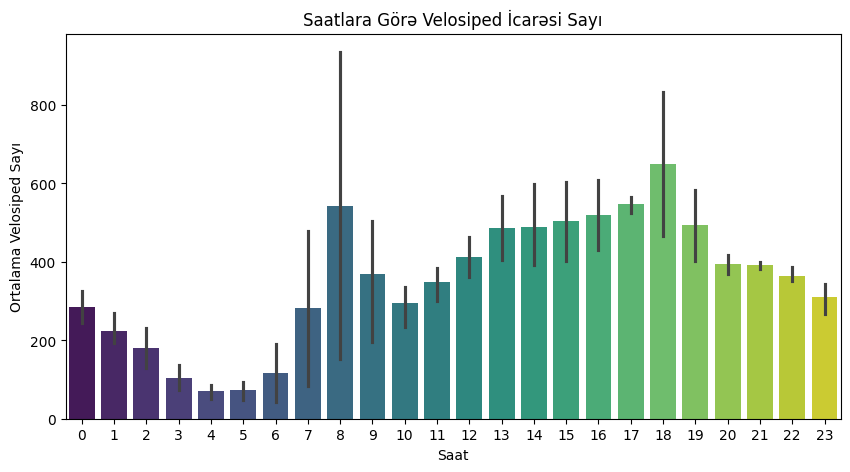

In [6]:
plt.figure(figsize=(10, 5))
sns.barplot(x='Hour', y='Rented Bike Count', palette='viridis', data=df)
plt.title('Saatlara Görə Velosiped İcarəsi Sayı')
plt.xlabel('Saat')
plt.ylabel('Ortalama Velosiped Sayı')

plt.show()

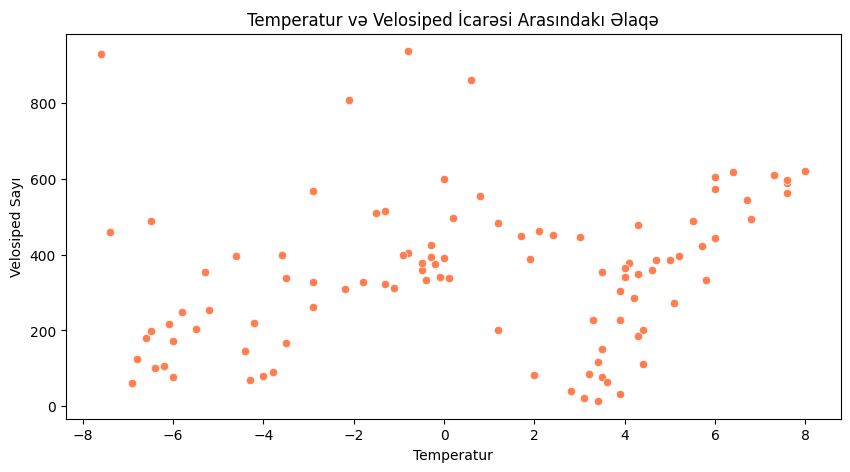

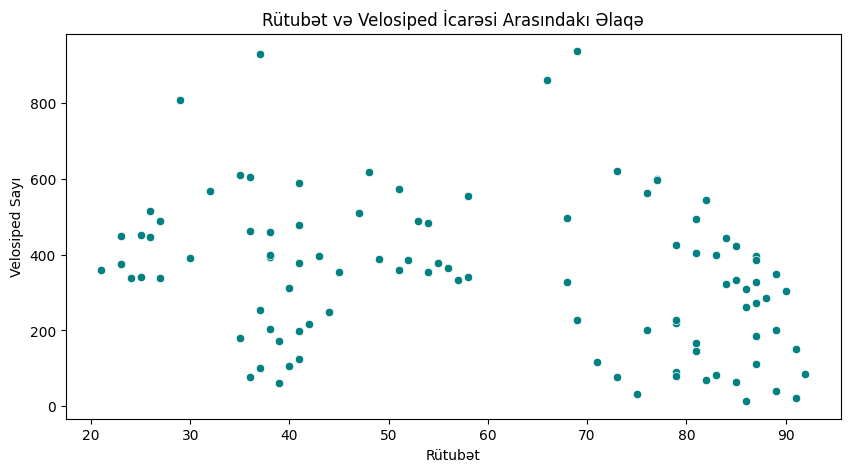

In [7]:
plt.figure(figsize=(10, 5))
sns.scatterplot(x='Temperature(C)', y='Rented Bike Count', data=df, color='coral')
plt.title('Temperatur və Velosiped İcarəsi Arasındakı Əlaqə')
plt.xlabel('Temperatur')
plt.ylabel('Velosiped Sayı')
plt.show()

plt.figure(figsize=(10, 5))
sns.scatterplot(x='Humidity(%)', y='Rented Bike Count', data=df, color='teal')
plt.title('Rütubət və Velosiped İcarəsi Arasındakı Əlaqə')
plt.xlabel('Rütubət')
plt.ylabel('Velosiped Sayı')
plt.show()

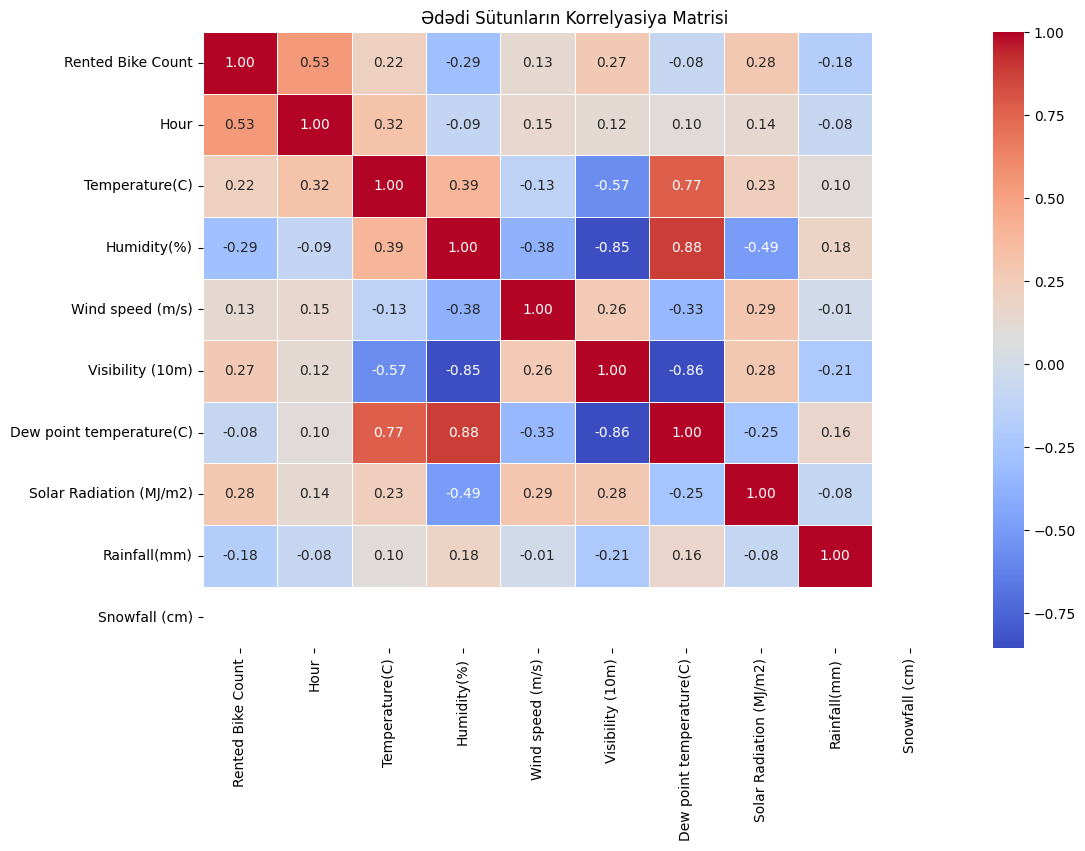

In [8]:
plt.figure(figsize=(12, 8))

num_cols = df.select_dtypes(include=['float64', 'int64']).drop(columns=['index'], errors='ignore')

corr_matrix = num_cols.corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Ədədi Sütunların Korrelyasiya Matrisi')
plt.show()

In [9]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

df['Month'] = df['Date'].dt.month
df['Day_of_Week'] = df['Date'].dt.dayofweek

In [14]:
print(df[['Date', 'Month', 'Day_of_Week']].head())

        Date  Month  Day_of_Week
0 2017-12-01     12            4
1 2017-12-01     12            4
2 2017-12-01     12            4
3 2017-12-01     12            4
4 2017-12-01     12            4


In [16]:
cat_cols = ['Seasons', 'Holiday', 'Functioning Day']

df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

In [19]:
df.head()

,index,Date,Rented Bike Count,Hour,Temperature(C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Month,Day_of_Week
0,0,2017-12-01,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0,12,4
1,1,2017-12-01,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0,12,4
2,2,2017-12-01,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0,12,4
3,3,2017-12-01,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0,12,4
4,4,2017-12-01,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0,12,4


In [20]:
df = df.drop(columns=['index', 'Date'], errors='ignore')

In [21]:
df.shape

(100, 12)

In [22]:
from sklearn.model_selection import train_test_split

In [23]:
X = df.drop(columns=['Rented Bike Count'])

In [24]:
y = df['Rented Bike Count']

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [26]:
X_train.shape

(80, 11)

In [27]:
X_test.shape

(20, 11)

In [28]:
from sklearn.linear_model import LinearRegression

In [29]:
model = LinearRegression()

In [30]:
model.fit(X_train, y_train)

LinearRegression()

In [31]:
from sklearn.tree import DecisionTreeRegressor

In [32]:
model_2 = DecisionTreeRegressor(random_state=42)

In [33]:
model_2.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

In [34]:
from sklearn.model_selection import GridSearchCV

In [35]:
param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10, 20]
}


grid_search = GridSearchCV(
   estimator=DecisionTreeRegressor(random_state=42),
   param_grid=param_grid,
   cv=5,
   scoring='r2',
   n_jobs= -1
)

grid_search.fit(X_train, y_train)

best_model_dt = grid_search.best_estimator_

print(grid_search.best_params_)

{'max_depth': 5, 'min_samples_split': 5}


In [36]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [37]:
model_pred = model.predict(X_test)

model_2_pred = model_2.predict(X_test)

best_model_pred = best_model_dt.predict(X_test)

In [38]:
def evaluate_model(y_true, y_pred):
  r2 = r2_score(y_true, y_pred)
  mae = mean_absolute_error(y_true, y_pred)
  mse = mean_squared_error(y_true, y_pred)
  return r2, mae, mse

model_r2, model_mae, model_mse = evaluate_model(y_test, model_pred)
model_2_r2, model_2_mae, model_2_mse = evaluate_model(y_test, model_2_pred)
best_dt_r2, best_dt_mae, best_dt_mse = evaluate_model(y_test, best_model_pred)

results = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree (Default)', 'Decision Tree (Tuned)'],
    'R2 Score': [model_r2, model_2_r2, best_dt_r2],
    'MAE': [model_mae, model_2_mae, best_dt_mae],
    'MSE': [model_mse, model_2_mse, best_dt_mse]
})

In [43]:
results

,Model,R2 Score,MAE,MSE
0,Linear Regression,0.273741,141.315521,50307.471143
1,Decision Tree (Default),0.706146,92.000000,20355.100000
2,Decision Tree (Tuned),0.450734,126.382654,38047.308397
